In [9]:
#---UPLOADING DATASETS---

from google.colab import files
uploaded = files.upload()  # select: bgdrainfallsubnatfull.csv, wfp_food_prices_bgd.csv, externaldebt_bgd.csv

import pandas as pd
import numpy as np

DIV_MAP = {
    'Barisal':'BD10', 'Chittagong':'BD20', 'Dhaka':'BD30', 'Khulna':'BD40',
    'Mymensingh':'BD45', 'Rajshahi':'BD50', 'Rangpur':'BD55', 'Sylhet':'BD60'
}
DIVISIONS = list(DIV_MAP.values())
YMIN, YMAX = 1999, 2024

Saving bgdrainfallsubnatfull.csv to bgdrainfallsubnatfull (2).csv
Saving externaldebt_bgd.csv to externaldebt_bgd (2).csv
Saving wfp_food_prices_bgd.csv to wfp_food_prices_bgd (2).csv


In [10]:
# --- 1) RAINFALL -> monthly, per division ---
rf = pd.read_csv('bgdrainfallsubnatfull.csv')
rf = rf[(rf['adm_level']==1) & (rf['PCODE'].isin(DIVISIONS))].copy()
rf['date'] = pd.to_datetime(rf['date'])
rf['year'] = rf['date'].dt.year
rf['month'] = rf['date'].dt.month
rf = rf[(rf['year']>=YMIN)&(rf['year']<=YMAX)]

rf_m = rf.groupby(['PCODE','year','month']).agg(
    rainfall_mm=('rfh','sum'),
    rainfall_historic_avg_mm=('rfh_avg','sum')
).reset_index()
rf_m['rainfall_anomaly_pct'] = (rf_m['rainfall_mm']-rf_m['rainfall_historic_avg_mm'])/rf_m['rainfall_historic_avg_mm']*100
rf_m = rf_m.rename(columns={'PCODE':'pcode'})
print("RAINFALL rows:", rf_m.shape)

RAINFALL rows: (2496, 6)


In [11]:
# --- 2) FOOD PRICES -> monthly avg USD/kg (USD/L for oil), per division ---
fp = pd.read_csv('wfp_food_prices_bgd.csv')
fp['date'] = pd.to_datetime(fp['date'], format='%d/%m/%Y')
fp['year'] = fp['date'].dt.year
fp['month'] = fp['date'].dt.month
fp = fp[(fp['year']>=YMIN)&(fp['year']<=YMAX)]
fp['pcode'] = fp['admin1'].map(DIV_MAP)
fp = fp[fp['pcode'].notna()]

RICE = ['Rice (coarse, BR-8/ 11/, Guti Sharna)','Rice (coarse)','Rice (coarse, Guti Sharna)',
        'Rice (medium grain)','Rice (Kajla)','Rice (Nurjahan)','Rice (Pyzam)',
        'Rice (BRRI-28)','Rice (BRRI-29)','Rice (BRRI-49)','Rice (Gazi)']
FLOUR = ['Wheat flour']
OIL   = ['Oil (palm)','Oil (mustard)','Oil (soybean, fortified)']
LENTILS = ['Lentils (masur)']

def unit_norm_price(sub):
    factor = np.where(sub['unit']=='100 KG', 100.0, 1.0)
    return sub['usdprice']/factor

groups = {'rice':RICE, 'flour':FLOUR, 'oil':OIL, 'lentils':LENTILS}
frames = []
for name, items in groups.items():
    s = fp[fp['commodity'].isin(items)].copy()
    s['norm_price'] = unit_norm_price(s)
    g = s.groupby(['pcode','year','month'])['norm_price'].mean().reset_index()
    unit_label = 'usd_per_l' if name=='oil' else 'usd_per_kg'
    g = g.rename(columns={'norm_price': f'{name}_price_{unit_label}'})
    frames.append(g)

from functools import reduce
fp_m = reduce(lambda a,b: pd.merge(a,b,on=['pcode','year','month'],how='outer'), frames)
price_cols = [c for c in fp_m.columns if c.endswith(('usd_per_kg','usd_per_l'))]
fp_m['avg_food_price_usd_per_kg'] = fp_m[price_cols].mean(axis=1)
print("FOOD PRICE rows:", fp_m.shape)

FOOD PRICE rows: (1498, 8)


In [12]:
# --- 3) EXTERNAL DEBT -> 3 indicators, annual -> broadcast to all months+divisions ---
dbt = pd.read_csv('externaldebt_bgd.csv')
IND = {
    'External debt stocks, total (DOD, current US$)': 'debt_stock_total_usd',
    'Debt service on external debt, total (TDS, current US$)': 'debt_service_total_usd',
    'External debt stocks (% of GNI)': 'debt_stock_pct_gni'
}
dbt = dbt[dbt['Indicator Name'].isin(IND.keys())]
dbt_w = dbt.pivot(index='Year', columns='Indicator Name', values='Value').rename(columns=IND).reset_index()
dbt_w = dbt_w.rename(columns={'Year':'year'})
dbt_w = dbt_w[(dbt_w['year']>=YMIN)&(dbt_w['year']<=YMAX)]

months = pd.DataFrame({'month': range(1,13)})
dbt_m = dbt_w.merge(months, how='cross').merge(pd.DataFrame({'pcode': DIVISIONS}), how='cross')
print("DEBT broadcast rows:", dbt_m.shape)

DEBT broadcast rows: (2496, 6)


In [13]:
# --- 4) MERGE onto full grid (8 div x 26yr x 12mo = 2496) ---
grid = pd.DataFrame({'pcode': DIVISIONS}).merge(
    pd.DataFrame({'year': range(YMIN, YMAX+1)}), how='cross').merge(
    pd.DataFrame({'month': range(1,13)}), how='cross')

merged = grid.merge(rf_m, on=['pcode','year','month'], how='left')
merged = merged.merge(fp_m, on=['pcode','year','month'], how='left')
merged = merged.merge(dbt_m, on=['pcode','year','month'], how='left')
merged['date'] = pd.to_datetime(dict(year=merged.year, month=merged.month, day=1))
merged = merged.sort_values(['pcode','date']).reset_index(drop=True)
print("FULL GRID:", merged.shape)
print("Nulls before interp:\n", merged.isna().sum())

FULL GRID: (2496, 15)
Nulls before interp:
 pcode                           0
year                            0
month                           0
rainfall_mm                     0
rainfall_historic_avg_mm        0
rainfall_anomaly_pct            0
rice_price_usd_per_kg        1409
flour_price_usd_per_kg       1393
oil_price_usd_per_l          1447
lentils_price_usd_per_kg     1432
avg_food_price_usd_per_kg     998
debt_service_total_usd          0
debt_stock_pct_gni              0
debt_stock_total_usd            0
date                            0
dtype: int64


In [14]:
# --- 5) INTERPOLATE (linear, per division) ---
num_cols = [c for c in merged.columns if c not in ('pcode','year','month','date')]
merged[num_cols] = merged.groupby('pcode')[num_cols].transform(
    lambda s: s.interpolate(method='linear', limit_direction='both')
)
before = merged.shape[0]
merged = merged.dropna(subset=num_cols)
print("Rows dropped (interp impossible):", before-merged.shape[0])
print("Final shape:", merged.shape)

merged.to_csv('merged_bgd_dataset.csv', index=False)
files.download('merged_bgd_dataset.csv')
merged.head(10)

Rows dropped (interp impossible): 0
Final shape: (2496, 15)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,pcode,year,month,rainfall_mm,rainfall_historic_avg_mm,rainfall_anomaly_pct,rice_price_usd_per_kg,flour_price_usd_per_kg,oil_price_usd_per_l,lentils_price_usd_per_kg,avg_food_price_usd_per_kg,debt_service_total_usd,debt_stock_pct_gni,debt_stock_total_usd,date
0,BD10,1999,1,11.396311,10.698173,6.525768,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-01-01
1,BD10,1999,2,17.702503,36.593272,-51.623612,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-02-01
2,BD10,1999,3,46.818182,99.255492,-52.830639,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-03-01
3,BD10,1999,4,33.883794,221.155743,-84.678764,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-04-01
4,BD10,1999,5,761.796030,508.682385,49.758681,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-05-01
5,BD10,1999,6,936.844006,888.344840,5.459498,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-06-01
6,BD10,1999,7,1434.829800,1092.248220,31.364810,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-07-01
7,BD10,1999,8,1061.614740,839.218540,26.500392,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-08-01
8,BD10,1999,9,994.562850,671.755974,48.054188,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-09-01
9,BD10,1999,10,657.459019,404.563576,62.510680,0.25,0.34,0.93,0.79,0.25,691197510.9,31.130251,1.644966e+10,1999-10-01


In [15]:
#IMPORTING MERGED DATASET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

m = pd.read_csv('merged_bgd_dataset.csv')
m['date'] = pd.to_datetime(m['date'])

In [16]:
# 1. Summary stats
print(m.describe().to_string())

              year        month  rainfall_mm  rainfall_historic_avg_mm  rainfall_anomaly_pct  rice_price_usd_per_kg  flour_price_usd_per_kg  oil_price_usd_per_l  lentils_price_usd_per_kg  avg_food_price_usd_per_kg  debt_service_total_usd  debt_stock_pct_gni  debt_stock_total_usd                           date
count  2496.000000  2496.000000  2496.000000               2496.000000           2496.000000            2496.000000             2496.000000          2496.000000               2496.000000                2496.000000            2.496000e+03         2496.000000          2.496000e+03                           2496
mean   2011.500000     6.500000   229.034303                226.876245              0.909740               0.384041                0.401572             0.945339                  0.929046                   0.629259            2.476423e+09           22.599197          4.154290e+10  2011-12-16 10:55:23.076923136
min    1999.000000     1.000000     2.167183                  3.108

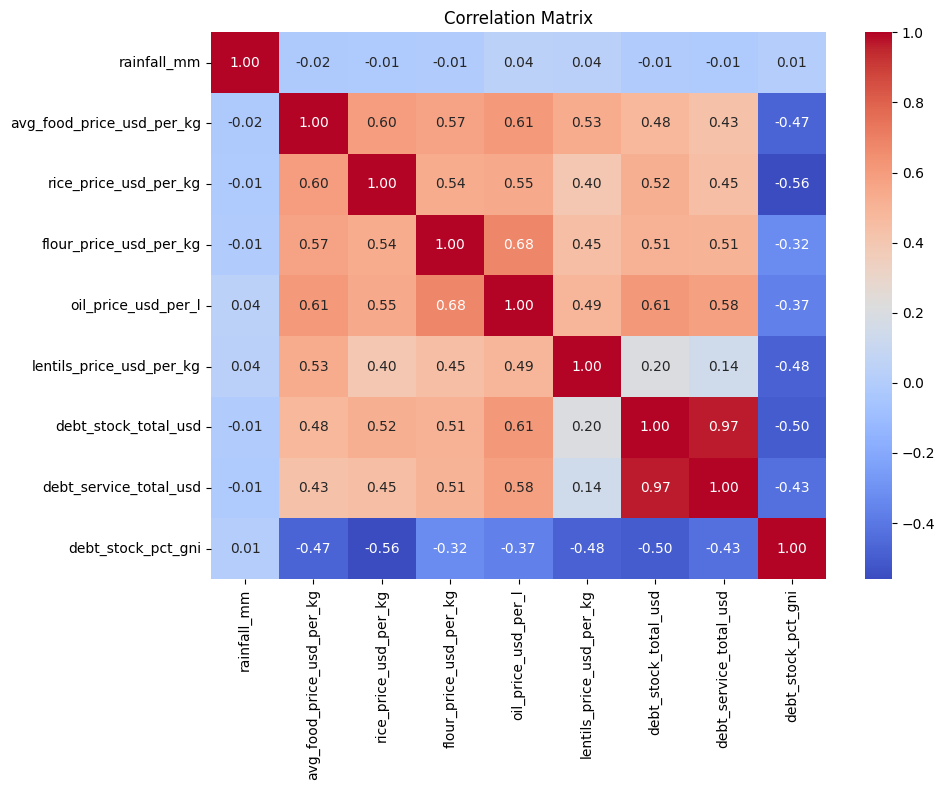

In [17]:
# 2. Correlation heatmap
cols = ['rainfall_mm','avg_food_price_usd_per_kg','rice_price_usd_per_kg','flour_price_usd_per_kg',
        'oil_price_usd_per_l','lentils_price_usd_per_kg','debt_stock_total_usd','debt_service_total_usd','debt_stock_pct_gni']
plt.figure(figsize=(10,8))
sns.heatmap(m[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout(); plt.savefig('eda_corr.png'); plt.show()

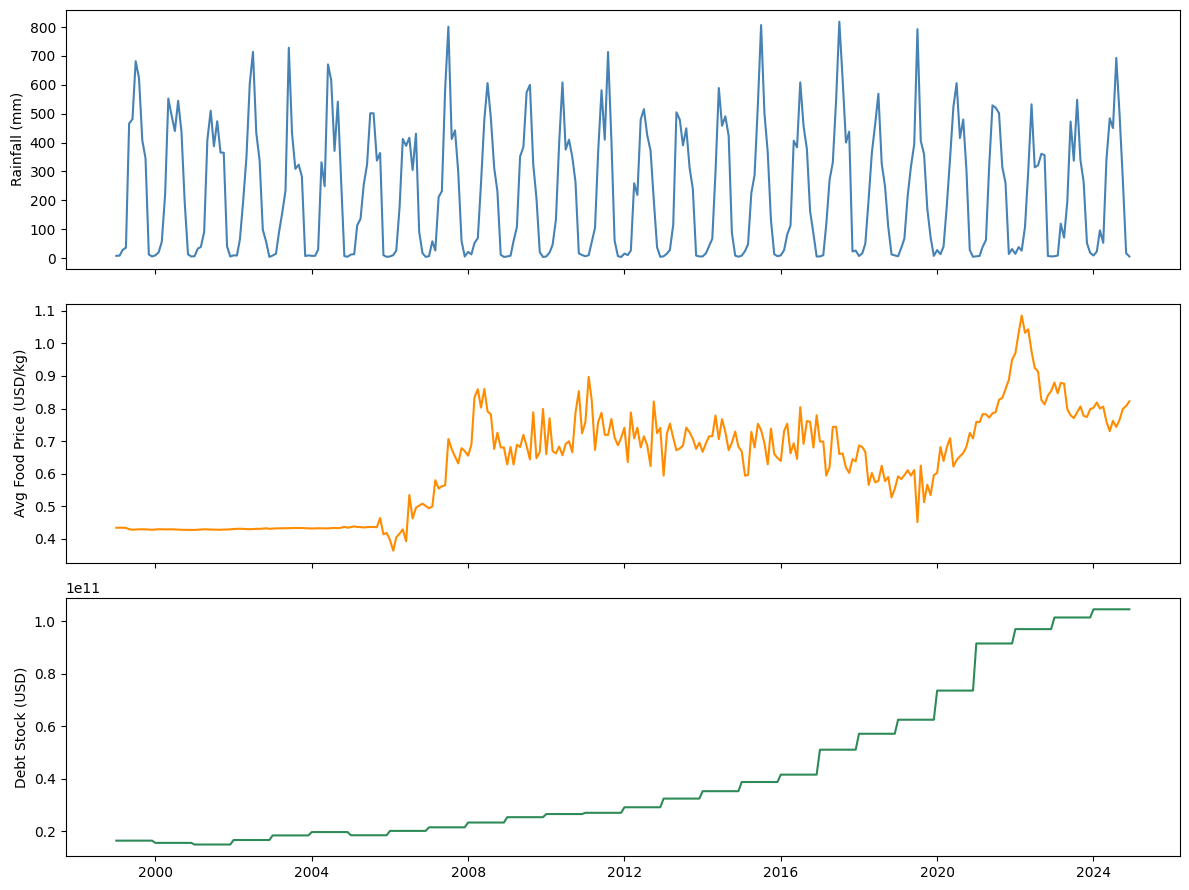

In [18]:
# 3. National monthly avg time series
nat = m.groupby('date')[['rainfall_mm','avg_food_price_usd_per_kg','debt_stock_total_usd']].mean().reset_index()
fig, ax = plt.subplots(3,1, figsize=(12,9), sharex=True)
ax[0].plot(nat['date'], nat['rainfall_mm'], color='steelblue'); ax[0].set_ylabel('Rainfall (mm)')
ax[1].plot(nat['date'], nat['avg_food_price_usd_per_kg'], color='darkorange'); ax[1].set_ylabel('Avg Food Price (USD/kg)')
ax[2].plot(nat['date'], nat['debt_stock_total_usd'], color='seagreen'); ax[2].set_ylabel('Debt Stock (USD)')
plt.tight_layout(); plt.savefig('eda_timeseries.png'); plt.show()

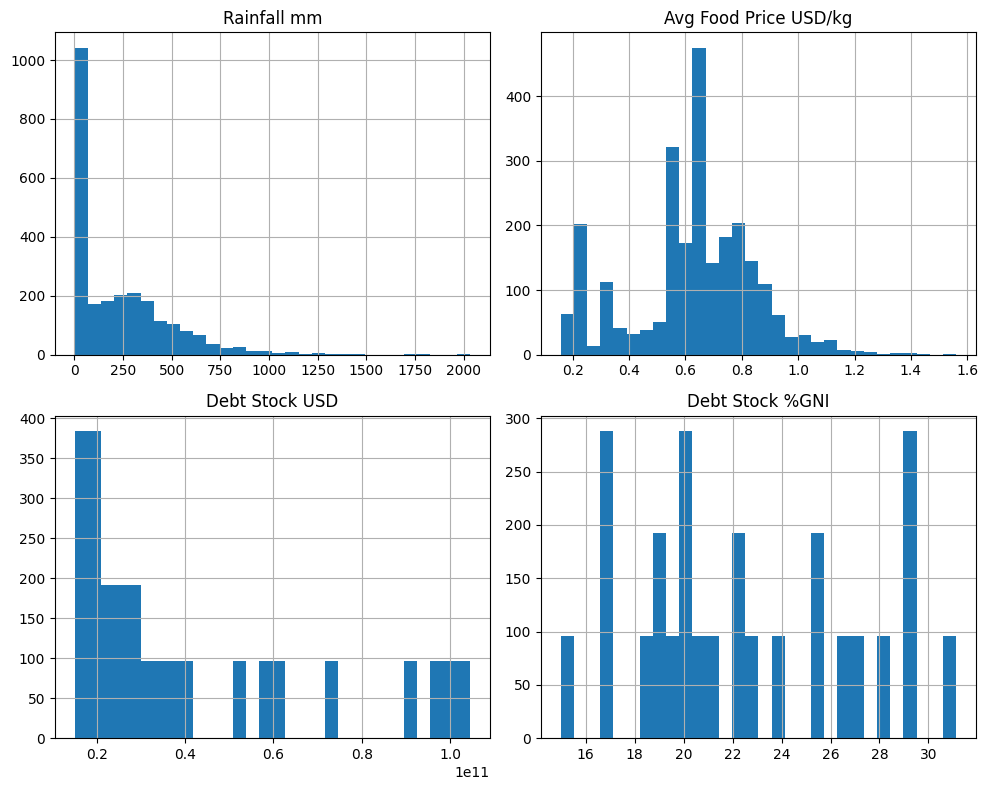

In [19]:
# 4. Distribution histograms
fig, axes = plt.subplots(2,2, figsize=(10,8))
m['rainfall_mm'].hist(ax=axes[0,0], bins=30); axes[0,0].set_title('Rainfall mm')
m['avg_food_price_usd_per_kg'].hist(ax=axes[0,1], bins=30); axes[0,1].set_title('Avg Food Price USD/kg')
m['debt_stock_total_usd'].hist(ax=axes[1,0], bins=30); axes[1,0].set_title('Debt Stock USD')
m['debt_stock_pct_gni'].hist(ax=axes[1,1], bins=30); axes[1,1].set_title('Debt Stock %GNI')
plt.tight_layout(); plt.savefig('eda_hist.png'); plt.show()

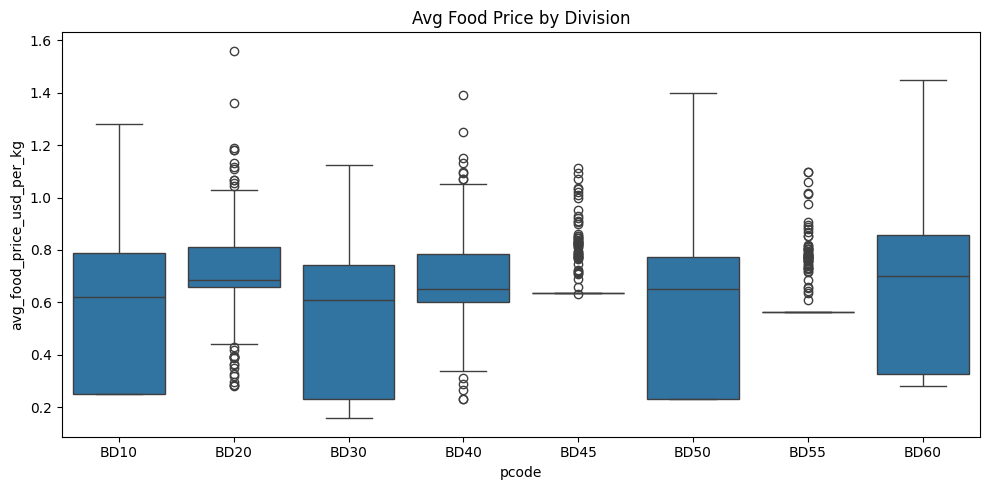

In [20]:
# 5. Food price by division
plt.figure(figsize=(10,5))
sns.boxplot(data=m, x='pcode', y='avg_food_price_usd_per_kg')
plt.title('Avg Food Price by Division')
plt.tight_layout(); plt.savefig('eda_box.png'); plt.show()

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

m = pd.read_csv('merged_bgd_dataset.csv')
m['date'] = pd.to_datetime(m['date'])

def run_models(X, y, cat_cols, num_cols, label):
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
    models = {
        'LinearRegression': LinearRegression(),
        'DecisionTree': DecisionTreeRegressor(max_depth=5, min_samples_split=20, random_state=1),
        'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_split=20, random_state=1)
    }
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=1)
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    print(f"\n=== {label} ===  n={len(X)}  features={list(X.columns)}")
    for name, mdl in models.items():
        pipe = Pipeline([('pre', pre), ('model', mdl)])
        pipe.fit(Xtr, ytr)
        pred_tr = pipe.predict(Xtr); pred_te = pipe.predict(Xte)
        r2_tr = r2_score(ytr, pred_tr); r2_te = r2_score(yte, pred_te)
        rmse_te = mean_squared_error(yte, pred_te)**0.5
        cv_scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2')
        print(f"{name:15s} | Train R2={r2_tr:.3f}  Test R2={r2_te:.3f}  Test RMSE={rmse_te:.4f}  CV R2={cv_scores.mean():.3f}+/-{cv_scores.std():.3f}  Gap(train-test)={r2_tr-r2_te:.3f}")

# RQ1: RAINFALL -> FOOD PRICE
y1 = m['avg_food_price_usd_per_kg']
XA = m[['rainfall_mm','rainfall_historic_avg_mm','rainfall_anomaly_pct','month','pcode']].copy()
run_models(XA, y1, cat_cols=['pcode'], num_cols=['rainfall_mm','rainfall_historic_avg_mm','rainfall_anomaly_pct','month'], label='RQ1-A: rainfall+month+division -> avg_food_price')

m_sorted = m.sort_values(['pcode','date'])
m_sorted['rainfall_lag3'] = m_sorted.groupby('pcode')['rainfall_mm'].shift(3)
m_lag = m_sorted.dropna(subset=['rainfall_lag3'])
XB = m_lag[['rainfall_mm','rainfall_lag3','rainfall_anomaly_pct','month','pcode']].copy()
yB = m_lag['avg_food_price_usd_per_kg']
run_models(XB, yB, cat_cols=['pcode'], num_cols=['rainfall_mm','rainfall_lag3','rainfall_anomaly_pct','month'], label='RQ1-B: rainfall+3mo_lag -> avg_food_price')

# RQ2: FOOD PRICE -> DEBT
y2 = m['debt_stock_total_usd']
XA2 = m[['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg']].copy()
run_models(XA2, y2, cat_cols=[], num_cols=list(XA2.columns), label='RQ2-A: food_prices -> debt_stock_usd (no year)')

XB2 = XA2.copy(); XB2['year'] = m['year']
run_models(XB2, y2, cat_cols=[], num_cols=list(XB2.columns), label='RQ2-B: food_prices+year -> debt_stock_usd (LEAKAGE CHECK)')

y2b = m['debt_stock_pct_gni']
run_models(XA2, y2b, cat_cols=[], num_cols=list(XA2.columns), label='RQ2-C: food_prices -> debt_stock_pct_gni (no year)')


=== RQ1-A: rainfall+month+division -> avg_food_price ===  n=2496  features=['rainfall_mm', 'rainfall_historic_avg_mm', 'rainfall_anomaly_pct', 'month', 'pcode']
LinearRegression | Train R2=0.076  Test R2=0.053  Test RMSE=0.2096  CV R2=0.064+/-0.018  Gap(train-test)=0.023
DecisionTree    | Train R2=0.086  Test R2=0.053  Test RMSE=0.2096  CV R2=0.051+/-0.015  Gap(train-test)=0.033
RandomForest    | Train R2=0.154  Test R2=0.040  Test RMSE=0.2110  CV R2=0.052+/-0.011  Gap(train-test)=0.113

=== RQ1-B: rainfall+3mo_lag -> avg_food_price ===  n=2472  features=['rainfall_mm', 'rainfall_lag3', 'rainfall_anomaly_pct', 'month', 'pcode']
LinearRegression | Train R2=0.074  Test R2=0.054  Test RMSE=0.1988  CV R2=0.062+/-0.010  Gap(train-test)=0.020
DecisionTree    | Train R2=0.125  Test R2=-0.072  Test RMSE=0.2116  CV R2=0.004+/-0.039  Gap(train-test)=0.196
RandomForest    | Train R2=0.177  Test R2=0.021  Test RMSE=0.2022  CV R2=0.037+/-0.017  Gap(train-test)=0.155

=== RQ2-A: food_prices -> debt

Aggregated rows: (208, 6)


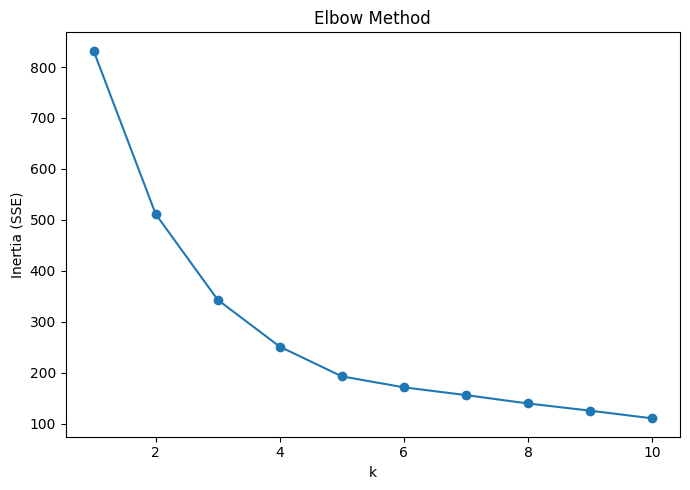

   rainfall_anomaly_pct  avg_food_price_usd_per_kg  debt_stock_pct_gni  \
0                26.276                      0.654              18.481   
1                -2.695                      0.438              28.168   
2               -11.601                      0.703              20.303   
3                 4.507                      0.835              21.316   

   debt_service_total_usd  risk_score  
0            3.152072e+09      -1.991  
1            7.204199e+08      -0.304  
2            1.669055e+09       0.266  
3            7.192337e+09       2.608  
risk_label
High Risk        71
Moderate Risk    66
Low Risk         40
Severe Risk      31
Name: count, dtype: int64
    pcode   risk_label
25   BD10  Severe Risk
51   BD20  Severe Risk
77   BD30  Severe Risk
103  BD40  Severe Risk
129  BD45  Severe Risk
155  BD50  Severe Risk
181  BD55  Severe Risk
207  BD60  Severe Risk


In [22]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

m = pd.read_csv('merged_bgd_dataset.csv')

# aggregate to year x division (risk grouping unit)
agg = m.groupby(['pcode','year']).agg(
    rainfall_anomaly_pct=('rainfall_anomaly_pct','mean'),
    avg_food_price_usd_per_kg=('avg_food_price_usd_per_kg','mean'),
    debt_stock_pct_gni=('debt_stock_pct_gni','mean'),
    debt_service_total_usd=('debt_service_total_usd','mean')
).reset_index()
print("Aggregated rows:", agg.shape)

feat_cols = ['rainfall_anomaly_pct','avg_food_price_usd_per_kg','debt_stock_pct_gni','debt_service_total_usd']
X = agg[feat_cols].copy()
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Elbow method
distortions = {}
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(Xs)
    distortions[k] = km.inertia_
plt.figure(figsize=(7,5))
plt.plot(list(distortions.keys()), list(distortions.values()), marker='o')
plt.xlabel('k'); plt.ylabel('Inertia (SSE)'); plt.title('Elbow Method')
plt.tight_layout(); plt.savefig('kmeans_elbow.png'); plt.show()

# k=4: low/moderate/high/severe risk
K = 4
km = KMeans(n_clusters=K, random_state=1, n_init=10)
agg['cluster'] = km.fit_predict(Xs)

centers_scaled = pd.DataFrame(km.cluster_centers_, columns=feat_cols)
centers_orig = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=feat_cols)
centers_orig['risk_score'] = (-centers_scaled['rainfall_anomaly_pct']) + centers_scaled['avg_food_price_usd_per_kg'] \
                              + centers_scaled['debt_stock_pct_gni'] + centers_scaled['debt_service_total_usd']
centers_orig = centers_orig.sort_values('risk_score').reset_index()
risk_labels = {row['index']: lbl for row, lbl in zip(centers_orig.to_dict('records'), ['Low Risk','Moderate Risk','High Risk','Severe Risk'])}
agg['risk_label'] = agg['cluster'].map(risk_labels)

print(centers_orig[feat_cols+['risk_score']].round(3))
print(agg['risk_label'].value_counts())
print(agg[agg['year']==2024][['pcode','risk_label']])

agg.to_csv('risk_clusters.csv', index=False)

In [23]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

m = pd.read_csv('merged_bgd_dataset.csv')

# ---- Final Model 1: rainfall -> food price (weak, LinearRegression for transparency) ----
X1 = m[['rainfall_mm','rainfall_historic_avg_mm','rainfall_anomaly_pct','month','pcode']]
y1 = m['avg_food_price_usd_per_kg']
pre1 = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['pcode'])], remainder='passthrough')
model1 = Pipeline([('pre', pre1), ('model', LinearRegression())]).fit(X1, y1)

# ---- Final Model 2: food prices -> debt_stock_total_usd (RandomForest, best R2, no leakage) ----
X2 = m[['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg']]
y2 = m['debt_stock_total_usd']
model2 = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_split=20, random_state=1).fit(X2, y2)

# ---- Final Model 3: KMeans risk clustering (year x division level) ----
agg = m.groupby(['pcode','year']).agg(
    rainfall_anomaly_pct=('rainfall_anomaly_pct','mean'),
    avg_food_price_usd_per_kg=('avg_food_price_usd_per_kg','mean'),
    debt_stock_pct_gni=('debt_stock_pct_gni','mean'),
    debt_service_total_usd=('debt_service_total_usd','mean')
).reset_index()
feat_cols = ['rainfall_anomaly_pct','avg_food_price_usd_per_kg','debt_stock_pct_gni','debt_service_total_usd']
scaler3 = StandardScaler().fit(agg[feat_cols])
km = KMeans(n_clusters=4, random_state=1, n_init=10).fit(scaler3.transform(agg[feat_cols]))
centers_scaled = pd.DataFrame(km.cluster_centers_, columns=feat_cols)
risk_score = (-centers_scaled['rainfall_anomaly_pct']) + centers_scaled['avg_food_price_usd_per_kg'] + centers_scaled['debt_stock_pct_gni'] + centers_scaled['debt_service_total_usd']
order = risk_score.sort_values().index.tolist()
risk_labels = {cl: lbl for cl, lbl in zip(order, ['Low Risk','Moderate Risk','High Risk','Severe Risk'])}

# =====================================================
# DEMO FUNCTIONS (what the live Colab demo calls)
# =====================================================
def demo_predict_food_price(rainfall_mm, rainfall_hist_avg_mm, month, pcode):
    anomaly = (rainfall_mm - rainfall_hist_avg_mm)/rainfall_hist_avg_mm*100
    row = pd.DataFrame([{'rainfall_mm':rainfall_mm,'rainfall_historic_avg_mm':rainfall_hist_avg_mm,
                          'rainfall_anomaly_pct':anomaly,'month':month,'pcode':pcode}])
    pred = model1.predict(row)[0]
    return round(pred,3)

def demo_predict_debt(rice, flour, oil, lentils):
    avg = np.mean([rice,flour,oil,lentils])
    row = pd.DataFrame([{'rice_price_usd_per_kg':rice,'flour_price_usd_per_kg':flour,
                          'oil_price_usd_per_l':oil,'lentils_price_usd_per_kg':lentils,
                          'avg_food_price_usd_per_kg':avg}])
    pred = model2.predict(row)[0]
    return round(pred,0)

def demo_predict_risk(rainfall_anomaly_pct, avg_food_price, debt_pct_gni, debt_service):
    row = pd.DataFrame([[rainfall_anomaly_pct, avg_food_price, debt_pct_gni, debt_service]], columns=feat_cols)
    row_s = scaler3.transform(row)
    cl = km.predict(row_s)[0]
    return risk_labels[cl]

# ---- TEST RUNS ----
print("TEST 1 - Food price prediction:")
print(" Dhaka, rainfall=50mm (hist_avg=200mm, drought), month=4:", demo_predict_food_price(50, 200, 4, 'BD30'))
print(" Dhaka, rainfall=250mm (hist_avg=200mm, normal), month=4:", demo_predict_food_price(250, 200, 4, 'BD30'))

print("\nTEST 2 - Debt prediction from food prices:")
print(" Low prices (rice=0.30,flour=0.35,oil=0.85,lentils=0.75):", demo_predict_debt(0.30,0.35,0.85,0.75))
print(" High prices (rice=0.60,flour=0.65,oil=1.8,lentils=1.4):", demo_predict_debt(0.60,0.65,1.8,1.4))

print("\nTEST 3 - Risk cluster:")
print(" Good rain, low price, low debt:", demo_predict_risk(30, 0.45, 18, 1e9))
print(" Drought, high price, high debt:", demo_predict_risk(-40, 0.9, 30, 8e9))

# =====================================================
# INTERACTIVE COLAB WIDGET UI
# =====================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

DIVISIONS = ['BD10','BD20','BD30','BD40','BD45','BD50','BD55','BD60']

out = widgets.Output()
tab1 = widgets.VBox([
    widgets.FloatText(value=150, description='Rainfall(mm):'),
    widgets.FloatText(value=200, description='Hist Avg(mm):'),
    widgets.IntSlider(value=6, min=1, max=12, description='Month:'),
    widgets.Dropdown(options=DIVISIONS, value='BD30', description='Division:'),
])
btn1 = widgets.Button(description='Predict Food Price')
def on_click1(b):
    with out:
        clear_output()
        r,h,mo,pc = [w.value for w in tab1.children]
        print(f"Predicted avg_food_price_usd_per_kg: {demo_predict_food_price(r,h,mo,pc)}")
btn1.on_click(on_click1)

tab2 = widgets.VBox([
    widgets.FloatText(value=0.40, description='Rice($/kg):'),
    widgets.FloatText(value=0.40, description='Flour($/kg):'),
    widgets.FloatText(value=0.90, description='Oil($/L):'),
    widgets.FloatText(value=0.90, description='Lentils($/kg):'),
])
btn2 = widgets.Button(description='Predict Debt Stock')
def on_click2(b):
    with out:
        clear_output()
        ri,fl,oi,le = [w.value for w in tab2.children]
        print(f"Predicted debt_stock_total_usd: {demo_predict_debt(ri,fl,oi,le):,.0f}")
btn2.on_click(on_click2)

tab3 = widgets.VBox([
    widgets.FloatText(value=0, description='Rain Anomaly%:'),
    widgets.FloatText(value=0.7, description='Avg Food$/kg:'),
    widgets.FloatText(value=22, description='Debt %GNI:'),
    widgets.FloatText(value=2e9, description='Debt Service$:'),
])
btn3 = widgets.Button(description='Predict Risk Cluster')
def on_click3(b):
    with out:
        clear_output()
        ra,fp,dg,ds = [w.value for w in tab3.children]
        print(f"Predicted risk_label: {demo_predict_risk(ra,fp,dg,ds)}")
btn3.on_click(on_click3)

display(widgets.HTML("<h3>Live Simulation Demo</h3>"))
display(widgets.HTML("<b>1. Rainfall -> Food Price</b>"), tab1, btn1)
display(widgets.HTML("<b>2. Food Price -> Debt</b>"), tab2, btn2)
display(widgets.HTML("<b>3. Risk Clustering</b>"), tab3, btn3)
display(out)

TEST 1 - Food price prediction:
 Dhaka, rainfall=50mm (hist_avg=200mm, drought), month=4: 0.547
 Dhaka, rainfall=250mm (hist_avg=200mm, normal), month=4: 0.537

TEST 2 - Debt prediction from food prices:
 Low prices (rice=0.30,flour=0.35,oil=0.85,lentils=0.75): 19978417716.0
 High prices (rice=0.60,flour=0.65,oil=1.8,lentils=1.4): 73754834998.0

TEST 3 - Risk cluster:
 Good rain, low price, low debt: Low Risk
 Drought, high price, high debt: Severe Risk


HTML(value='<h3>Live Simulation Demo</h3>')

HTML(value='<b>1. Rainfall -> Food Price</b>')

Button(description='Predict Food Price', style=ButtonStyle())

HTML(value='<b>2. Food Price -> Debt</b>')

Button(description='Predict Debt Stock', style=ButtonStyle())

HTML(value='<b>3. Risk Clustering</b>')

Button(description='Predict Risk Cluster', style=ButtonStyle())

Output()